In [1]:
import numpy as np
np.set_printoptions(legacy='1.25')
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import scipy.stats as st
from statsmodels.tsa.stattools import acf
from re import search, compile

from functions import *

from Models import LayersPoissonModel



In [2]:
model_name = 'big'
prior_name = 'big'
proposer_name = 'big_transdimensionality_individual'
n_iter = 100000
folder_name = 'rjmcmc_individual_80'
n_chains = 8

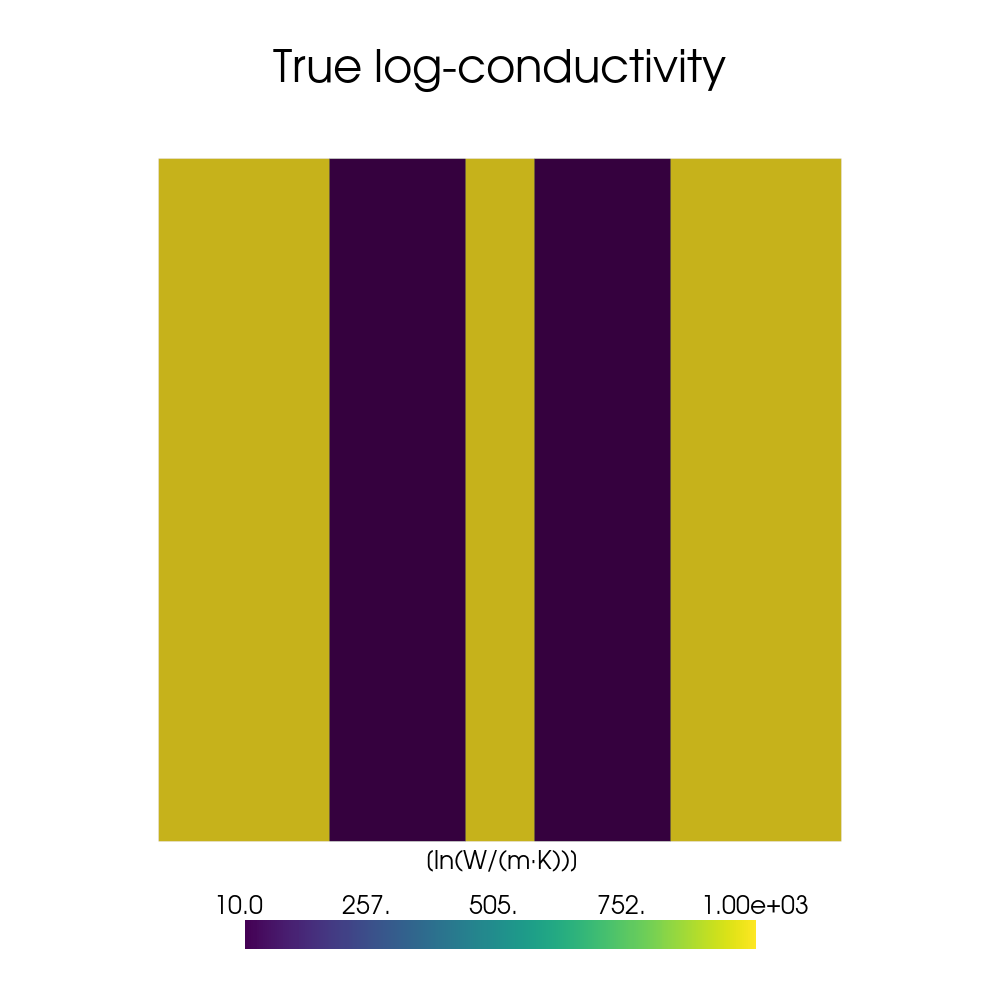

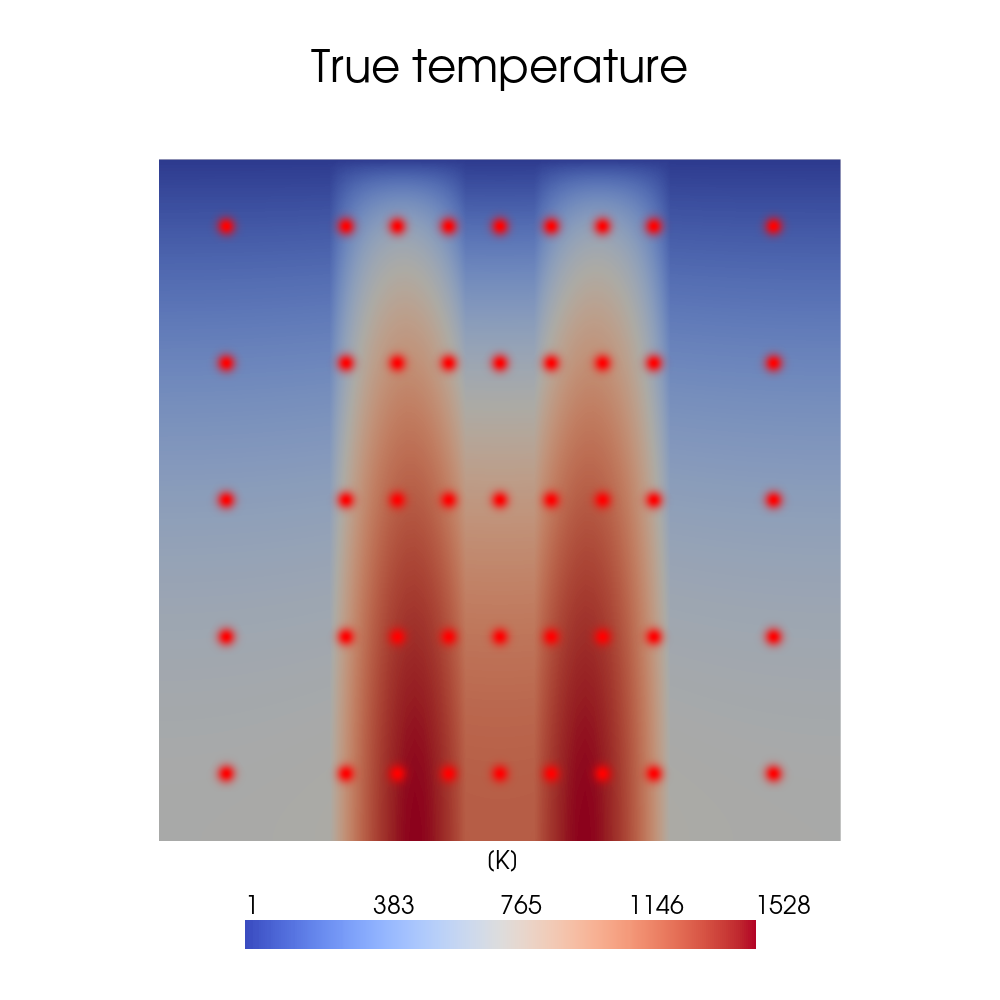

In [3]:
Model = extract_model(model_name)
Prior = extract_prior(prior_name)
Proposer = extract_proposer(proposer_name)

Model.visualize("true_log-conductivity")
#plotter.screenshot("plots/true_logconductivity.png")

Model.visualize("true_temperature")
#plotter.screenshot("plots/true_temperature.png")


In [4]:
#EXTRACT THE CHAINS

df = pd.read_csv("../simulation_data/"+folder_name+"/chain_1.csv", index_col=0)
for i in range(1,n_chains):
    df = pd.concat([df,pd.read_csv("../simulation_data/"+folder_name+"/chain_"+str(i+1)+".csv", index_col=0)])

df

,lksigma,lnk_sigma,width_sigma,psplit,pmerge,dim,lnk_0,lnk_1,lnk_2,lnk_3,...,u_43,u_44,acceptance,ull,propose_time,conductivity_time,prior_time,solve_time,ull_time,accept-reject_time
0,30.0,0.1,NaN,0.333333,0.333333,5,6.492533,6.494724,8.887423,6.658637,...,1825.045875,965.600681,0.000000,-111047.494504,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,30.0,0.1,NaN,0.333333,0.333333,5,6.492533,6.494724,8.887423,6.658637,...,1825.045875,965.600681,0.000000,-111047.494504,0.000195,0.008216,0.000343,0.023498,0.013746,0.000019
2,30.0,0.1,NaN,0.333333,0.333333,5,6.492533,6.494724,8.887423,6.947575,...,1819.445490,963.213696,0.333333,-110854.378429,0.000087,0.007142,0.000348,0.024697,0.011627,0.000181
3,30.0,0.1,NaN,0.333333,0.333333,4,6.492533,7.691074,6.947575,1.791797,...,1776.182819,949.007075,0.500000,-109968.668427,0.000324,0.005639,0.000282,0.026901,0.008892,0.000037
4,30.0,0.1,NaN,0.333333,0.333333,4,6.492533,7.691074,6.947575,1.791797,...,1776.182819,949.007075,0.400000,-109968.668427,0.000077,0.006796,0.000505,0.021981,0.009123,0.000018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99996,30.0,0.1,NaN,0.333333,0.333333,11,8.273320,4.831429,4.270370,4.899492,...,643.106920,295.707592,0.244367,-30.701308,0.000151,0.011621,0.000729,0.038892,0.020892,0.000026
99997,30.0,0.1,NaN,0.333333,0.333333,11,8.273320,4.831429,4.270370,4.899492,...,643.106920,295.707592,0.244365,-30.701308,0.000131,0.012074,0.000774,0.039594,0.017851,0.000021
99998,30.0,0.1,NaN,0.333333,0.333333,11,8.273320,4.831429,4.270370,4.899492,...,643.106920,295.707592,0.244362,-30.701308,0.000211,0.012351,0.000844,0.038750,0.017327,0.000002
99999,30.0,0.1,NaN,0.333333,0.333333,11,8.273320,4.831429,4.270370,4.899492,...,643.106920,295.707592,0.244360,-30.701308,0.000135,0.011998,0.000750,0.039587,0.017844,0.000025


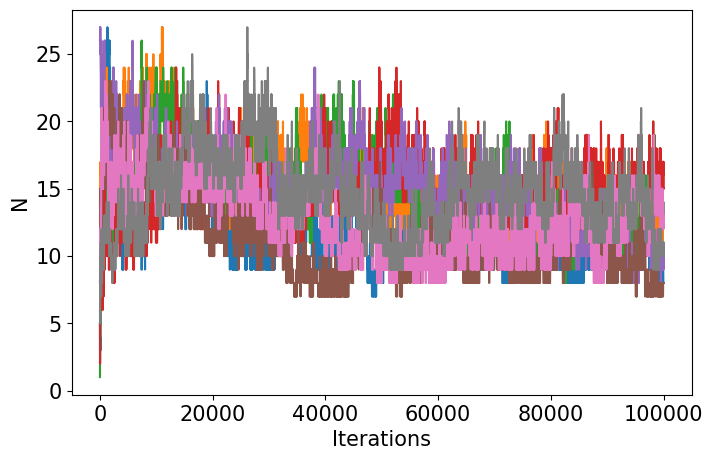

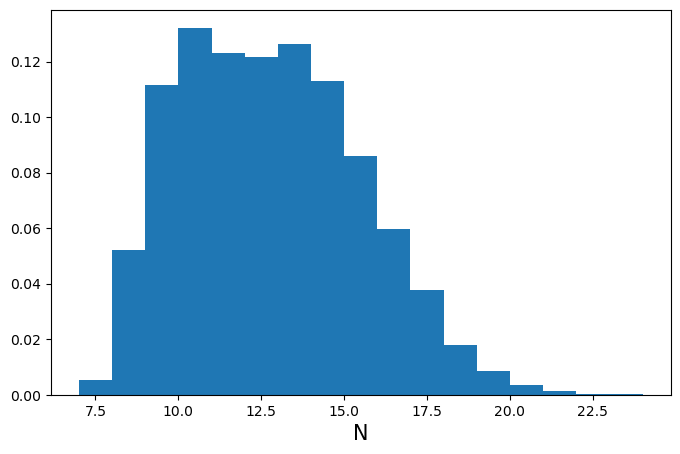

12.290571688566228 2.689603916152178


In [5]:
#EXTRACT DIMENSION DATA

fig, ax = plt.subplots(figsize=(8,5))
for i in range(n_chains):
    ax.plot(range(n_iter+1), df.dim.to_numpy()[i*(n_iter+1):(i+1)*(n_iter+1)])
ax.set_xlabel('Iterations', fontsize=15)
ax.set_ylabel('N', fontsize=15)
ax.tick_params(axis='both', labelsize=15)
#fig.savefig("transdimensionality-paper-els-cas-templates/figs/dimension_time_evolution.png")
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.set_xlabel('N', fontsize=15)
dim_array = np.array([df.dim.to_numpy()[i*(n_iter+1)+n_iter//2:(i+1)*(n_iter+1)] for i in range(n_chains)]).reshape(n_chains*(n_iter//2+1))
ax.hist(dim_array, density=True, bins=17)
#fig.savefig("transdimensionality-paper-els-cas-templates/figs/dimension_hist.png")
plt.show()
print(np.mean(dim_array), np.std(dim_array))


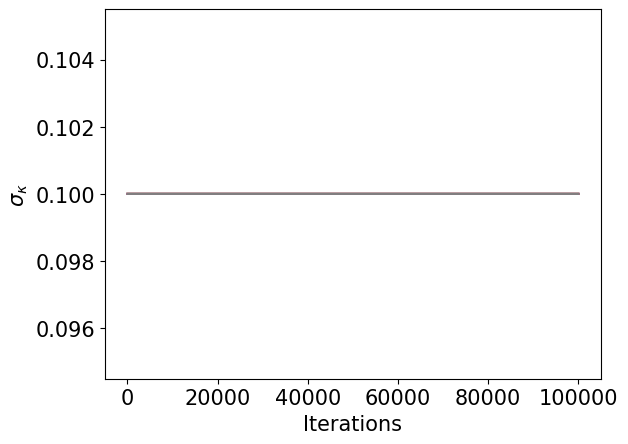

In [6]:
#EXTRACT ADAPTIVITY DATA

fig, ax = plt.subplots()
for i in range(n_chains):
    ax.plot(range(n_iter+1), df.lnk_sigma.to_numpy()[i*(n_iter+1):(i+1)*(n_iter+1)])
ax.set_xlabel("Iterations", fontsize=15)
ax.set_ylabel(r'$\sigma_{\kappa}$', fontsize=15)
ax.tick_params(axis='both', labelsize=15)
#fig.savefig("transdimensionality-paper-els-cas-templates/figs/lnk_sigma.png")
plt.show()

# Loglikelihood

In [7]:
def plot_loglikelihood(Model, df, xmin=0, ymin=None, ymax=None, title=None):
    dif = Model.eval(Model.measurements[:,:-1], "true_temperature") - Model.measurements[:,-1]
    target = -0.5*np.linalg.matmul(np.linalg.matmul(dif, Model.invcov), dif)
    target_ctat = (-Model.invcov.shape[0]/2)*np.log(2*np.pi)-0.5*np.log(np.linalg.det(np.linalg.inv(Model.invcov)))
    target_llk = target + target_ctat

    fig, ax = plt.subplots(figsize=(12,8))
    for i in range(n_chains):
        ax.plot(range(xmin,n_iter+1), df.ull.to_numpy()[(i)*(n_iter+1)+xmin:(i+1)*(n_iter+1)]+target_ctat)
    ax.hlines(target_llk, xmin=xmin, xmax=n_iter, colors='black', linestyles='--', label = 'target = '+str(round(target_llk,3)))
    ax.tick_params(axis='both', labelsize=25)
    ax.set_xlabel('Iterations', fontsize=25)
    ax.set_ylabel('Loglikelihood', fontsize=25)
    ax.set_title(title, fontsize=25)
    ax.set_ylim(ymin,ymax)
    ax.legend(prop={'size': 25})
    plt.show()

    return fig, ax

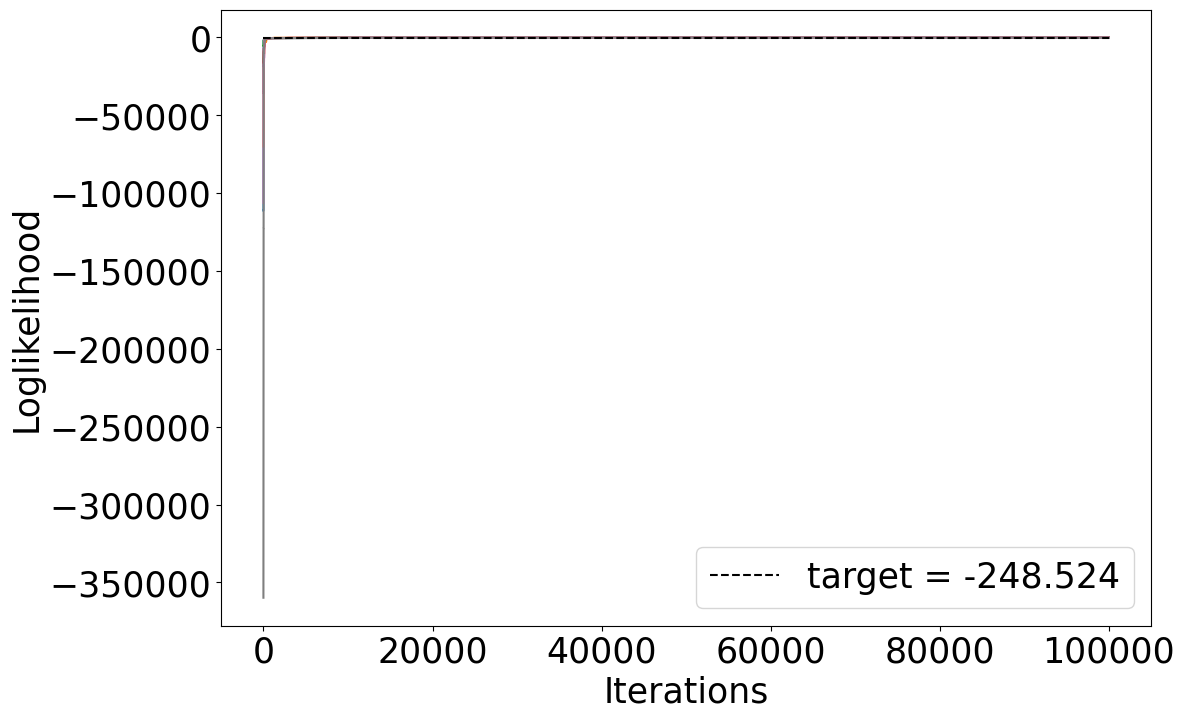

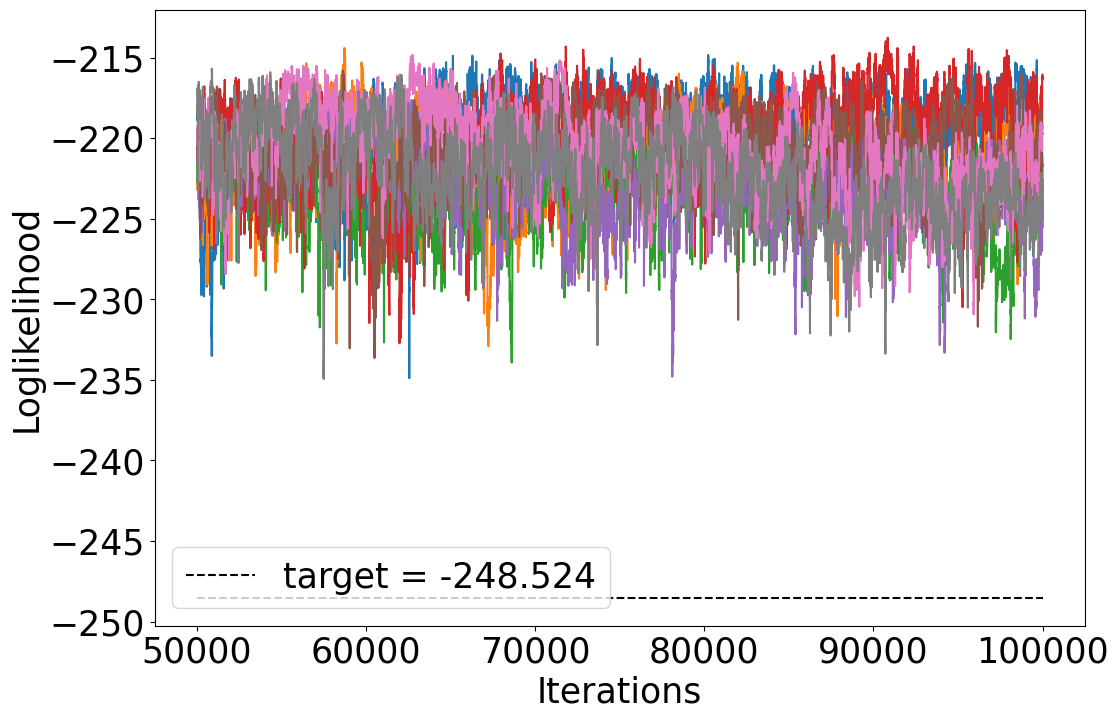

In [8]:
#GENERATE LIKELIHOOD DATA

plot_loglikelihood(Model, df, xmin=0, ymin=None, ymax=None, title=None)
plot_loglikelihood(Model, df, xmin=n_iter//2, ymin=None, ymax=None, title=None)

plt.show()

# Acceptance

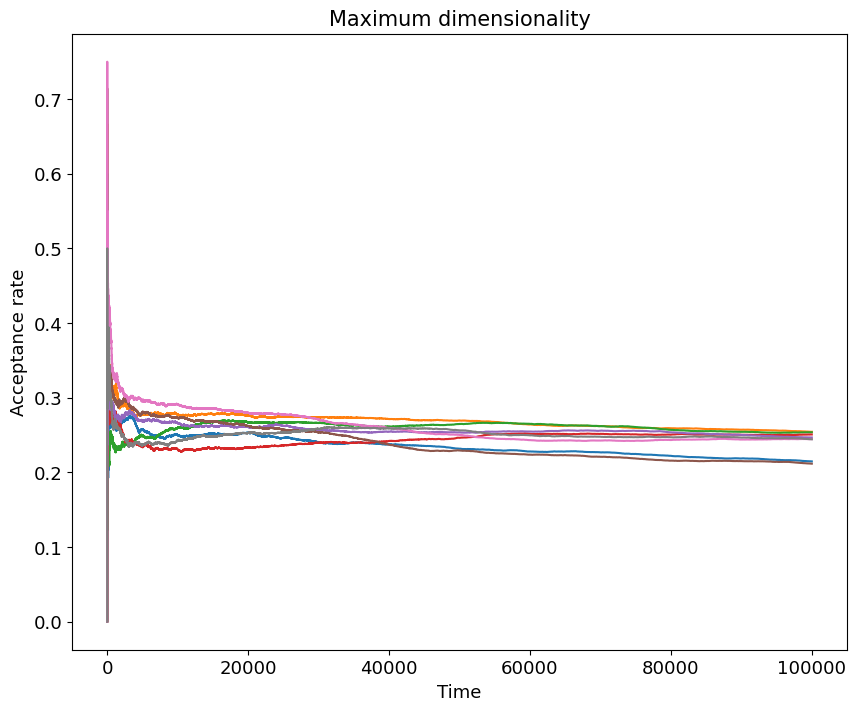

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Maximum dimensionality'}, xlabel='Time', ylabel='Acceptance rate'>)

In [9]:
#EXTRACT ACCEPTANCE DATA

def plot_acceptance(df, xmin=0):
    fig, ax = plt.subplots(figsize=(10,8))
    for i in range(n_chains):
        ax.plot(range(xmin,n_iter+1), df.acceptance.to_numpy()[i*(n_iter+1)+xmin:(i+1)*(n_iter+1)])
    ax.set_xlabel('Time', fontsize=13)
    ax.set_ylabel('Acceptance rate', fontsize=13)
    ax.set_title("Maximum dimensionality", fontsize=15)
    ax.tick_params(axis='both', labelsize=13)
    plt.show()
    return fig, ax

plot_acceptance(df, xmin=0)

In [10]:
def generate_columnwise_logconductivities(df, n_iter, n_chains):
    n_cols = len([col for col in df.columns if search(compile("lnk_+[0-9]"), col)!=None])
    lnks = df[['lnk_'+str(i) for i in range(n_cols)]].to_numpy()
    widths = df[['width_'+str(i) for i in range(n_cols-1)]].to_numpy()
    lnks = [lnks[np.arange(len(lnks)),np.argmin(((np.nan_to_num(np.cumsum(widths, axis=1),nan=1))*n_cols+0.5)<=i, axis=1)] for i in range(1,n_cols+1)]
    lnks = np.array(lnks).T
    lnks = np.array([lnks[i*(n_iter+1):(i+1)*(n_iter+1),:] for i in range(n_chains)])
    return lnks

def generate_columnwise_truelogconductivities(model_name):
    with open('../test_data/models.json', 'r') as f:
                model_metadata = json.load(f)[model_name]
    f.close()
    true_params = [model_metadata['true_dim'],model_metadata['true_lnks'],model_metadata['true_widths']]
    widths = list((np.array(true_params[2])*model_metadata['n_squares']).astype(int))
    widths.append(model_metadata['n_squares']-sum(widths))
    lnks = np.repeat(np.array(true_params[1]).reshape(-1,1), widths)
    return lnks

lnks = generate_columnwise_logconductivities(df, n_iter, n_chains)
true_lnks = generate_columnwise_truelogconductivities(model_name)

lnks_mean = np.mean(lnks[:,n_iter//2:,:].reshape((lnks[:,n_iter//2:,:].shape[0]*lnks[:,n_iter//2:,:].shape[1],lnks.shape[2])), axis=0)
lnks_std = np.std(lnks[:,n_iter//2:,:].reshape((lnks[:,n_iter//2:,:].shape[0]*lnks[:,n_iter//2:,:].shape[1],lnks.shape[2])), axis=0)

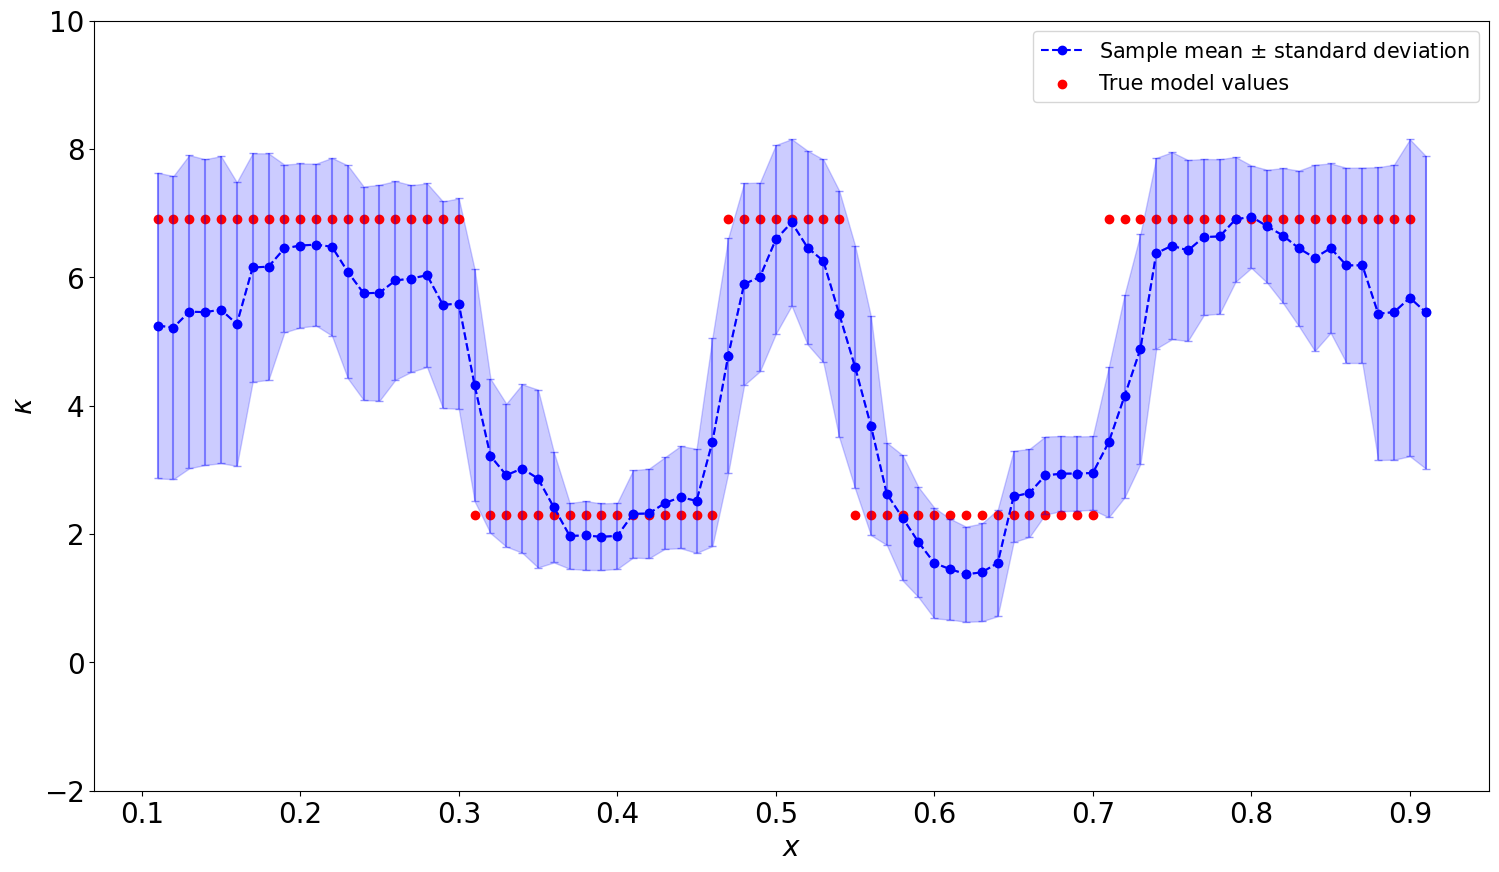

(<Figure size 1800x1000 with 1 Axes>, <Axes: xlabel='$x$', ylabel='$\\kappa$'>)

In [11]:
def plot_lnks(lnks, true_lnks, title=None):
    fig, ax = plt.subplots(figsize=(18,10))
    ax.plot(range(1,1+lnks.shape[-1]), lnks_mean, 'b--o', label=r'Sample mean $\pm$ standard deviation')
    ax.errorbar(range(1,1+lnks.shape[-1]), lnks_mean, yerr=lnks_std, fmt='--o', c='b', capsize=3, alpha=0.4)
    ax.fill_between(range(1,1+lnks.shape[-1]), lnks_mean-lnks_std, lnks_mean+lnks_std, alpha=0.2, color='b')
    ax.scatter(range(1,1+true_lnks.shape[0]), true_lnks, c='r', label=r'True model values')
    ax.set_xlabel(r'$x$',fontsize=20)
    ax.set_ylabel(r'$\kappa$',fontsize=20)
    ax.set_title(title, fontsize=25)
    ax.set_xticklabels(np.round(np.arange(0,1.1,0.1),1))
    ax.set_ylim(-2,10)
    ax.tick_params(axis='both', labelsize=20)
    ax.legend(prop={'size':15})
    #fig.savefig('plots/lnks_all_columns_mean_and_std.png')
    plt.show()
    return fig, ax

plot_lnks(lnks, true_lnks)


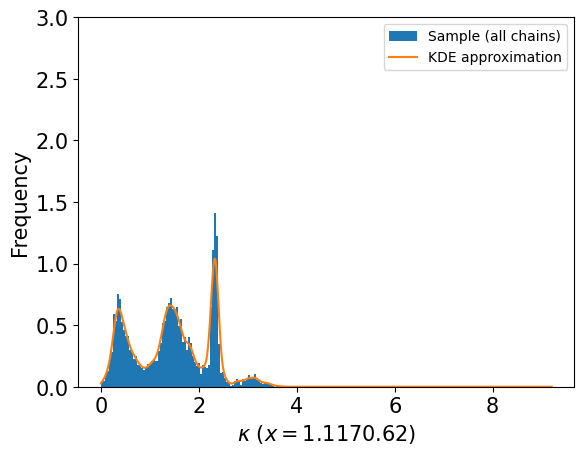

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\kappa$ ($x=$1.117$0.62$)', ylabel='Frequency'>)

In [12]:
#MULTIMODES

def plot_lnks_hist(lnks, col, lnk_min, lnk_max, title=None):
    fig, ax = plt.subplots()
    ax.hist(lnks[:,n_iter//2:,col].reshape(n_chains*(n_iter//2+1)), bins='fd', density=True, label='Sample (all chains)')
    ax.plot(np.linspace(lnk_min, lnk_max, 1000), st.gaussian_kde(lnks[:,n_iter//2:,col].reshape(n_chains*(n_iter//2+1)), bw_method='scott').pdf(np.linspace(lnk_min, lnk_max, 1000)), label='KDE approximation')
    ax.set_xlabel(r'$\kappa$ ($x=$'+str(round(col*1/lnks.shape[-1]+0.5,3))+r'$0.62$)',fontsize=15)
    ax.set_ylabel('Frequency',fontsize=15)
    ax.tick_params(axis='both', labelsize=15)
    ax.set_ylim(0,3)
    ax.set_title(title, fontsize=20)
    ax.legend()
    #fig.savefig("plots/multimodes_all_columns.png")
    plt.show()
    return fig, ax

plot_lnks_hist(lnks, 50, np.log(1), np.log(1e4))

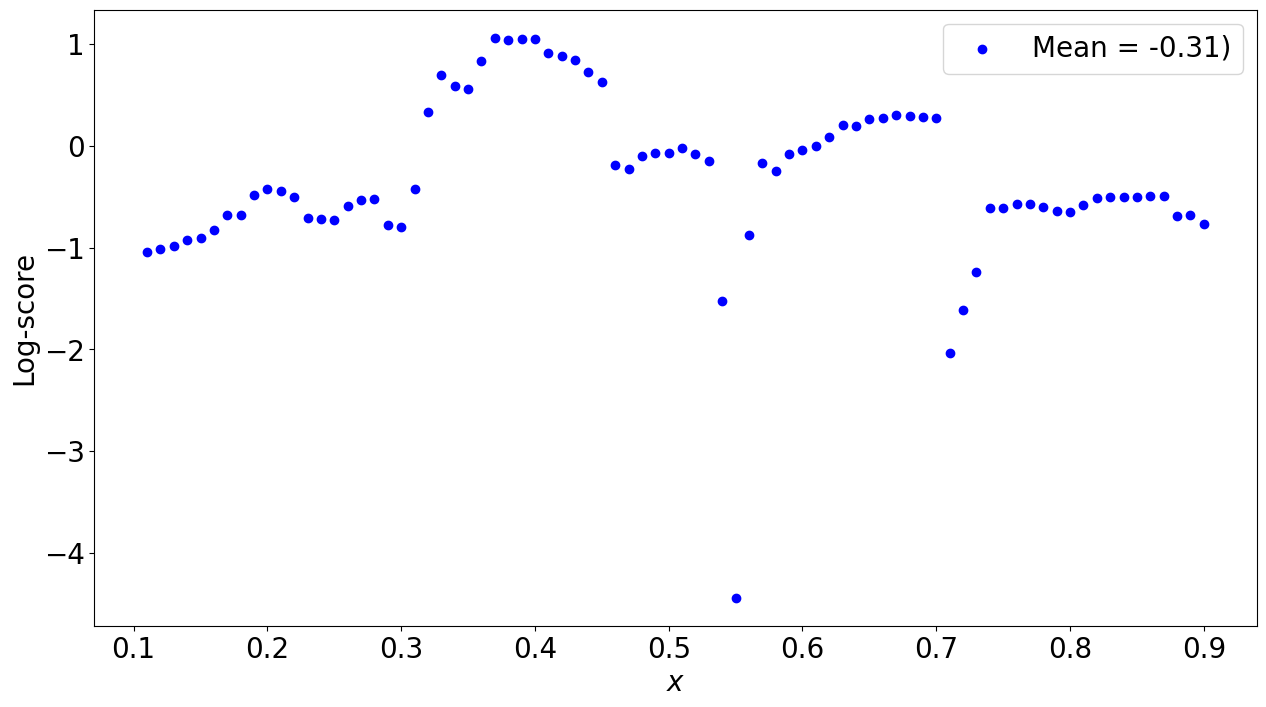

(<Figure size 1500x800 with 1 Axes>, <Axes: xlabel='$x$', ylabel='Log-score'>)

In [13]:
def plot_columnwise_logscores(lnks, true_lnks):
    kdes = [st.gaussian_kde(lnks[:,n_iter//2:,:].reshape((lnks[:,n_iter//2:,:].shape[0]*lnks[:,n_iter//2:,:].shape[1],lnks.shape[-1]))[:,col].T, bw_method='scott') for col in range(lnks.shape[-1])]
    pdf_kde = np.array([kdes[col].pdf(true_lnks[col])[0] for col in range(true_lnks.shape[0])])
    fig, ax = plt.subplots(figsize=(15,8))
    ax.scatter(range(1,1+true_lnks.shape[0]), np.log(pdf_kde), c='b', label='Mean = '+str(np.round(np.mean(np.log(pdf_kde)), 2))+')')
    ax.set_xlabel(r'$x$',fontsize=20)
    ax.set_ylabel('Log-score',fontsize=20)
    ax.legend(prop={'size': 20})
    ax.set_xticklabels(np.round(np.arange(0,1.1,0.1),1))
    ax.tick_params(axis='both', labelsize=20)
    plt.show()
    return fig, ax

plot_columnwise_logscores(lnks, true_lnks)

In [14]:
#TEMPERATURE MEASUREMENTS
def compute_temperature_metrics(df, n_iter, n_chains, Model):
    n_measurements = Model.measurements.shape[0]
    lksigma = Model.lksigma
    us = []
    for i in range(n_chains):
        us.append(df[['u_'+str(i) for i in range(n_measurements)]].to_numpy()[i*(n_iter+1):(i+1)*(n_iter+1)])
    us = np.array(us)

    #Relative error
    eps = np.linalg.norm(Model.measurements[:,-1]-np.mean(us[:,n_iter//2:,:].reshape((n_chains*(n_iter//2+1),n_measurements)),axis=0))/np.linalg.norm(Model.measurements[:,-1])

    #rRMSE
    rRMSE = np.sqrt(np.sum(((Model.measurements[:,-1]-us[:,n_iter//2:,:].reshape((n_chains*(n_iter//2+1),n_measurements)))**2).flatten())/(n_chains*n_measurements*n_iter//2-1))/lksigma

    #logscore
    logscore = -n_measurements/2*np.log(2*np.pi*lksigma*lksigma)-np.sum((Model.measurements[:,-1]-np.mean(us[:,n_iter//2:,:].reshape((n_chains*(n_iter//2+1),n_measurements)),axis=0))**2)/(2*lksigma*lksigma)

    return eps, rRMSE, logscore

eps, rRMSE, logscore = compute_temperature_metrics(df, n_iter, n_chains, Model)
eps, rRMSE, logscore

(0.05316771193775958, 1.7252335579512623, -254.576731977024)

In [15]:
from matplotlib import animation

with open('layers_metadata_5.json', 'r') as f:
    layers_metadata = json.load(f)
f.close()
true_params = [layers_metadata['true_dim'],layers_metadata['true_lnks'],layers_metadata['true_widths']]
measurements_df = pd.read_csv('layers_measurements_5.csv', index_col=0)
measurements = measurements_df[['x','y']].to_numpy()
Model = LayersPoissonModel(true_params, measurements, n_squares=layers_metadata['n_squares'], f_val=layers_metadata['f_val'], lksigma=layers_metadata['lksigma'], orientation=layers_metadata['orientation'])
Model.measurements[:,-1] = measurements_df['measured'].to_numpy()
Model.set_conductivity(params = [n_cols, lnks_all_columns[0,0], [1/n_cols for _ in range(n_cols-1)]])
Model.solve()
temperatures = Model.domain.geometry.x.copy()
temperatures[:,-1] = Model.uh.x.array.real.copy()
temperatures = np.array(sorted(temperatures,key=lambda x: (x[1],x[0])))

fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].set_xticks(np.linspace(0-0.5,80-0.5,11))
ax[0].set_xticklabels(np.round(np.linspace(0,1,11),2))
ax[0].set_yticks(np.linspace(0-0.5,80-0.5,11))
ax[0].set_yticklabels(np.round(np.linspace(0,1,11),2))
imshow_logconductivity = ax[0].imshow(np.matmul(np.ones(80).reshape(-1,1),lnks_all_columns[0,0].reshape(-1,1).T), vmin=np.log(1), vmax=np.log(1e4), origin='lower')
imshow_logconductivity
cbar_logconductivity = fig.colorbar(imshow_logconductivity, ax=ax[0], orientation='horizontal')
cbar_logconductivity.set_label(r"$\ln(W/(m \cdot K))$")


ax[1].set_xticks(np.linspace(0-0.5,80-0.5,11))
ax[1].set_xticklabels(np.round(np.linspace(0,1,11),2))
ax[1].set_yticks(np.linspace(0-0.5,80-0.5,11))
ax[1].set_yticklabels(np.round(np.linspace(0,1,11),2))
imshow_temperature = ax[1].imshow(temperatures[:,-1].reshape((81,81)), vmin=1, vmax=1600, origin='lower', cmap=cm.coolwarm)
cbar_temperature = fig.colorbar(imshow_temperature, ax=ax[1], orientation='horizontal')
cbar_temperature.set_label(r"$K$")

def init():
    imshow_logconductivity.set_data(np.matmul(np.ones(80).reshape(-1,1),lnks_all_columns[0,0].reshape(-1,1).T))
    imshow_temperature.set_data(temperatures[:,-1].reshape((81,81)))
    return [imshow_logconductivity, imshow_temperature]

def animate(i):
    t = i*100
    ax[0].set_title(str(t))
    ax[1].set_title(str(t))
    imshow_logconductivity.set_array(np.matmul(np.ones(80).reshape(-1,1),lnks_all_columns[0,t].reshape(-1,1).T))
    Model.set_conductivity(params = [n_cols, lnks_all_columns[0,t], [1/n_cols for _ in range(n_cols-1)]])
    Model.solve()
    temperatures = Model.domain.geometry.x.copy()
    temperatures[:,-1] = Model.uh.x.array.real.copy()
    temperatures = np.array(sorted(temperatures,key=lambda x: (x[1],x[0])))
    imshow_temperature.set_array(temperatures[:,-1].reshape((81,81)))
    return [imshow_logconductivity, imshow_temperature]


anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=1000)
anim.save('all_columns_1.mp4', fps=100)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'layers_metadata_5.json'

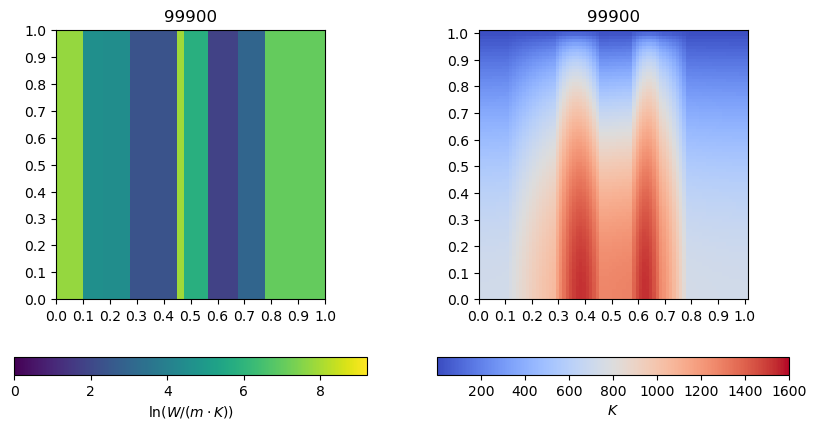

In [ ]:
with open('layers_metadata_5.json', 'r') as f:
    layers_metadata = json.load(f)
f.close()
true_params = [layers_metadata['true_dim'],layers_metadata['true_lnks'],layers_metadata['true_widths']]
measurements_df = pd.read_csv('layers_measurements_5.csv', index_col=0)
measurements = measurements_df[['x','y']].to_numpy()
Model = LayersPoissonModel(true_params, measurements, n_squares=layers_metadata['n_squares'], f_val=layers_metadata['f_val'], lksigma=layers_metadata['lksigma'], orientation=layers_metadata['orientation'])
Model.measurements[:,-1] = measurements_df['measured'].to_numpy()
Model.set_conductivity(params = [n_cols, lnks_rjmcmc[0,0], [1/n_cols for _ in range(n_cols-1)]])
Model.solve()
temperatures = Model.domain.geometry.x.copy()
temperatures[:,-1] = Model.uh.x.array.real.copy()
temperatures = np.array(sorted(temperatures,key=lambda x: (x[1],x[0])))

fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].set_xticks(np.linspace(0-0.5,80-0.5,11))
ax[0].set_xticklabels(np.round(np.linspace(0,1,11),2))
ax[0].set_yticks(np.linspace(0-0.5,80-0.5,11))
ax[0].set_yticklabels(np.round(np.linspace(0,1,11),2))
imshow_logconductivity = ax[0].imshow(np.matmul(np.ones(80).reshape(-1,1),lnks_rjmcmc[0,0].reshape(-1,1).T), vmin=np.log(1), vmax=np.log(1e4), origin='lower')
imshow_logconductivity
cbar_logconductivity = fig.colorbar(imshow_logconductivity, ax=ax[0], orientation='horizontal')
cbar_logconductivity.set_label(r"$\ln(W/(m \cdot K))$")


ax[1].set_xticks(np.linspace(0-0.5,80-0.5,11))
ax[1].set_xticklabels(np.round(np.linspace(0,1,11),2))
ax[1].set_yticks(np.linspace(0-0.5,80-0.5,11))
ax[1].set_yticklabels(np.round(np.linspace(0,1,11),2))
imshow_temperature = ax[1].imshow(temperatures[:,-1].reshape((81,81)), vmin=1, vmax=1600, origin='lower', cmap=cm.coolwarm)
cbar_temperature = fig.colorbar(imshow_temperature, ax=ax[1], orientation='horizontal')
cbar_temperature.set_label(r"$K$")

def init():
    imshow_logconductivity.set_data(np.matmul(np.ones(80).reshape(-1,1),lnks_rjmcmc[0,0].reshape(-1,1).T))
    imshow_temperature.set_data(temperatures[:,-1].reshape((81,81)))
    return [imshow_logconductivity, imshow_temperature]

def animate(i):
    t = i*100
    ax[0].set_title(str(t))
    ax[1].set_title(str(t))
    imshow_logconductivity.set_array(np.matmul(np.ones(80).reshape(-1,1),lnks_rjmcmc[0,t].reshape(-1,1).T))
    Model.set_conductivity(params = [n_cols, lnks_rjmcmc[0,t], [1/n_cols for _ in range(n_cols-1)]])
    Model.solve()
    temperatures = Model.domain.geometry.x.copy()
    temperatures[:,-1] = Model.uh.x.array.real.copy()
    temperatures = np.array(sorted(temperatures,key=lambda x: (x[1],x[0])))
    imshow_temperature.set_array(temperatures[:,-1].reshape((81,81)))
    return [imshow_logconductivity, imshow_temperature]


anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=1000)
anim.save('rjmcmc_1.gif', fps=100)

plt.show()

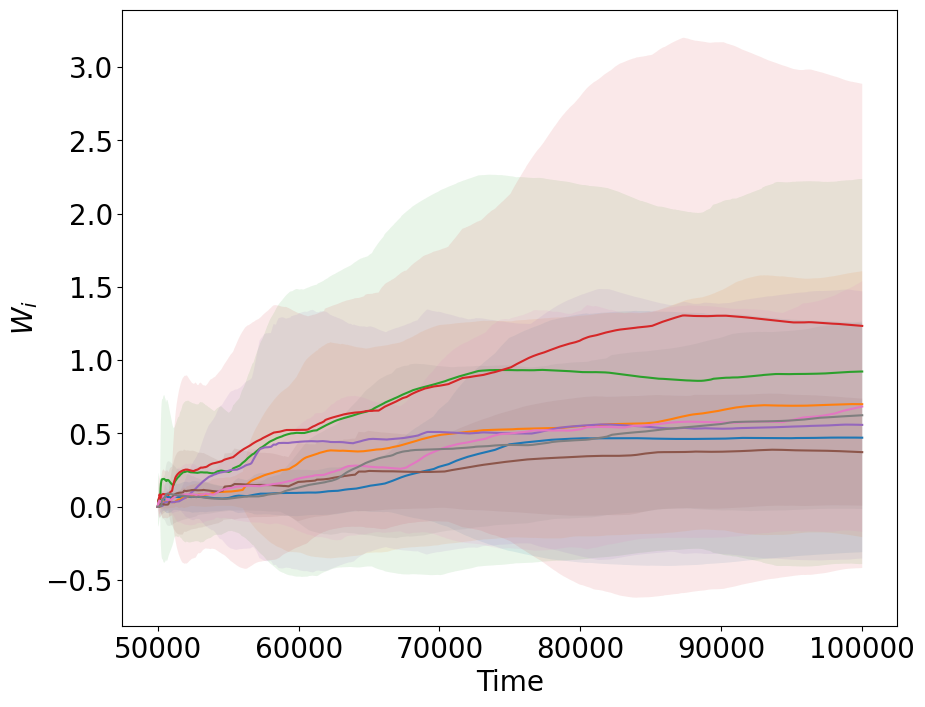

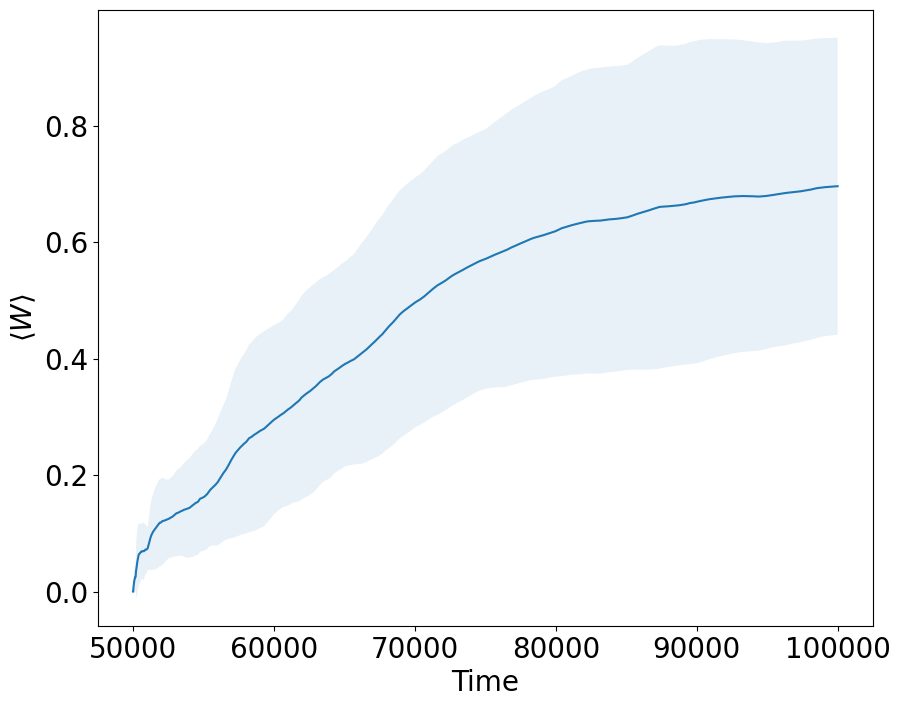

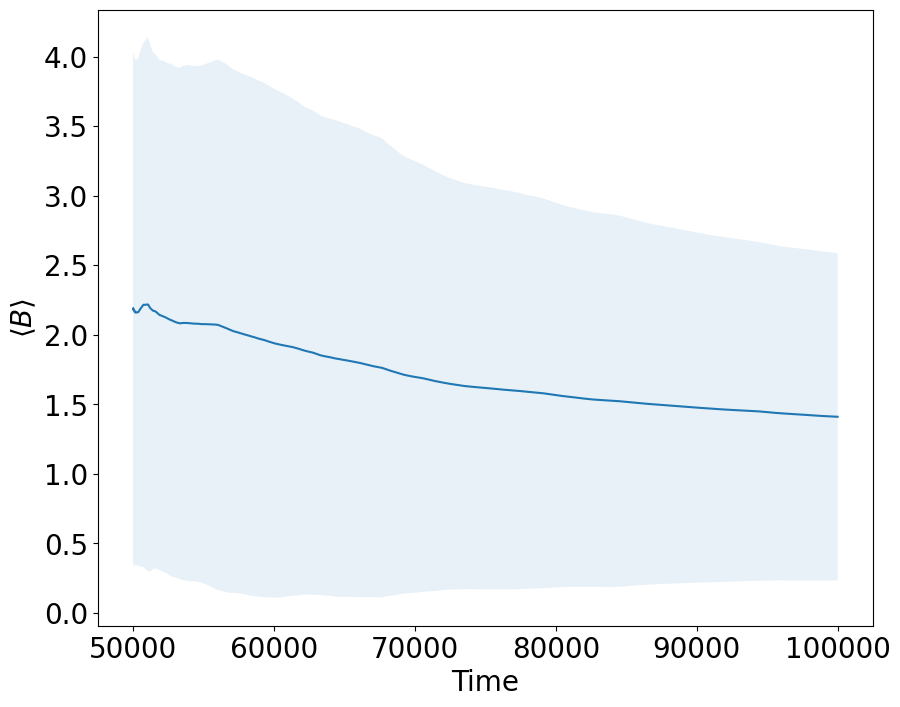

(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='$W_i$'>,
 <Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='$\\langle W \\rangle$'>,
 <Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='$\\langle B \\rangle$'>)

In [ ]:
#GENERATE CONVERGENCE DATA
def compute_within_variance(lnks, n_iter):
    W = np.mean((np.cumsum(lnks[:,n_iter//2:,:]**2, axis=1)/np.matmul(np.array(range(1,n_iter//2+2)).reshape(-1,1), np.ones(lnks[:,n_iter//2:,:].shape[2]).reshape(-1,1).T))-(np.cumsum(lnks[:,n_iter//2:,:], axis=1)/np.matmul(np.array(range(1,n_iter//2+2)).reshape(-1,1), np.ones(lnks[:,n_iter//2:,:].shape[2]).reshape(-1,1).T))**2, axis=0)
    return W

def compute_between_variance(lnks, n_iter):   
    B = np.mean((np.cumsum(lnks[:,n_iter//2:,:], axis=1)/np.matmul(np.array(range(1,n_iter//2+2)).reshape(-1,1), np.ones(lnks[:,n_iter//2:,:].shape[2]).reshape(-1,1).T))**2, axis=0) - np.mean((np.cumsum(lnks[:,n_iter//2:,:], axis=1)/np.matmul(np.array(range(1,n_iter//2+2)).reshape(-1,1), np.ones(lnks[:,n_iter//2:,:].shape[2]).reshape(-1,1).T)), axis=0)**2
    return B

def plot_within_and_between_variances(lnks, n_iter, n_chains, title=None):
    W = compute_within_variance(lnks, n_iter)
    W_means = np.mean((np.cumsum(lnks[:,n_iter//2:,:]**2, axis=1)/np.matmul(np.array(range(1,n_iter//2+2)).reshape(-1,1), np.ones(lnks[:,n_iter//2:,:].shape[2]).reshape(-1,1).T))-(np.cumsum(lnks[:,n_iter//2:,:], axis=1)/np.matmul(np.array(range(1,n_iter//2+2)).reshape(-1,1), np.ones(lnks[:,n_iter//2:,:].shape[2]).reshape(-1,1).T))**2, axis=2)
    W_stds = np.std((np.cumsum(lnks[:,n_iter//2:,:]**2, axis=1)/np.matmul(np.array(range(1,n_iter//2+2)).reshape(-1,1), np.ones(lnks[:,n_iter//2:,:].shape[2]).reshape(-1,1).T))-(np.cumsum(lnks[:,n_iter//2:,:], axis=1)/np.matmul(np.array(range(1,n_iter//2+2)).reshape(-1,1), np.ones(lnks[:,n_iter//2:,:].shape[2]).reshape(-1,1).T))**2, axis=2)
    mean_W = np.mean(W_means, axis=0)
    std_W = np.std(W_means, axis=0)
    B = compute_between_variance(lnks, n_iter)
    B_means = np.mean(np.mean((np.cumsum(lnks[:,n_iter//2:,:], axis=1)/np.matmul(np.array(range(1,n_iter//2+2)).reshape(-1,1), np.ones(lnks[:,n_iter//2:,:].shape[2]).reshape(-1,1).T))**2, axis=0) - np.mean((np.cumsum(lnks[:,n_iter//2:,:], axis=1)/np.matmul(np.array(range(1,n_iter//2+2)).reshape(-1,1), np.ones(lnks[:,n_iter//2:,:].shape[2]).reshape(-1,1).T)), axis=0)**2, axis=1)
    B_stds = np.std(np.mean((np.cumsum(lnks[:,n_iter//2:,:], axis=1)/np.matmul(np.array(range(1,n_iter//2+2)).reshape(-1,1), np.ones(lnks[:,n_iter//2:,:].shape[2]).reshape(-1,1).T))**2, axis=0) - np.mean((np.cumsum(lnks[:,n_iter//2:,:], axis=1)/np.matmul(np.array(range(1,n_iter//2+2)).reshape(-1,1), np.ones(lnks[:,n_iter//2:,:].shape[2]).reshape(-1,1).T)), axis=0)**2, axis=1)

    fig1, ax1 = plt.subplots(figsize=(10,8))
    fig2, ax2 = plt.subplots(figsize=(10,8))
    fig3, ax3 = plt.subplots(figsize=(10,8))
    for i in range(n_chains):
        ax1.plot(range(50000, n_iter+1), W_means[i,:])
        ax1.fill_between(range(50000, n_iter+1), W_means[i,:]-W_stds[i,:], W_means[i,:]+W_stds[i,:], alpha=0.1)


    ax1.set_xlabel('Time', fontsize=20)
    ax1.set_ylabel(r'$W_i$', fontsize=20)
    ax1.set_title(title, fontsize=20)
    ax1.tick_params(axis='both', labelsize=20)

    ax2.plot(range(50000, n_iter+1), mean_W)
    ax2.fill_between(range(50000, n_iter+1),  mean_W-std_W, mean_W+std_W, alpha=0.1)
    ax2.set_xlabel('Time', fontsize=20)
    ax2.set_ylabel(r'$\langle W \rangle$', fontsize=20)
    ax2.tick_params(axis='both', labelsize=20)

    ax3.plot(range(50000, n_iter+1), B_means)
    ax3.fill_between(range(50000, n_iter+1),  B_means-B_stds, B_means+B_stds, alpha=0.1)
    ax3.set_xlabel('Time', fontsize=20)
    ax3.set_ylabel(r'$\langle B \rangle$', fontsize=20)
    ax3.tick_params(axis='both', labelsize=20)

    """fig1.savefig("plots/within_variance_all_columns.png")
    fig2.savefig("plots/within_variance_rjmcmc.png")
    fig3.savefig("plots/average_within_variance.png")
    fig4.savefig("plots/average_between_variance.png")"""
    plt.show()

    return fig1, ax1, fig2, ax2, fig3, ax3

plot_within_and_between_variances(lnks, n_iter, n_chains)

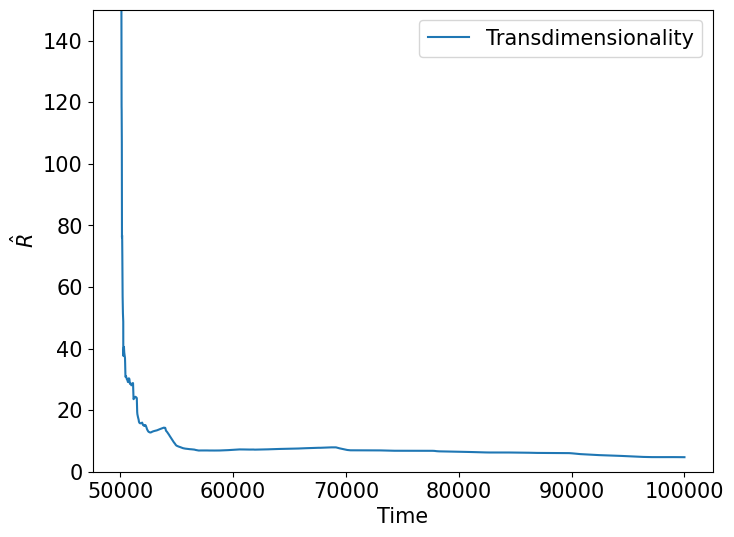

(<Figure size 800x600 with 1 Axes>, <Axes: xlabel='Time', ylabel='$\\hat{R}$'>)

In [ ]:
def compute_GR(lnks, n_iter, tol=1e-10):
    W, B = compute_within_variance(lnks, n_iter), compute_between_variance(lnks, n_iter)
    imin = np.max(np.argmax((W>tol).astype(int), axis=0))+1
    GR = np.sqrt(((np.arange(1,n_iter//2+2)-1)/np.arange(1,n_iter//2+2))[imin_rjmcmc:]+np.max(B[imin_rjmcmc:]/W[imin_rjmcmc:], axis=1))
    return GR

def plot_gr(lnks, n_iter, tol=1e-10):
    W, B = compute_within_variance(lnks, n_iter), compute_between_variance(lnks, n_iter)
    imin = np.max(np.argmax((W>tol).astype(int), axis=0))+1
    GR = np.sqrt(((np.arange(1,n_iter//2+2)-1)/np.arange(1,n_iter//2+2))[imin:]+np.max(B[imin:]/W[imin:], axis=1))
    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(range(imin+n_iter//2, n_iter+1), np.sqrt(((np.arange(1,n_iter//2+2)-1)/np.arange(1,n_iter//2+2))[imin:]+np.max(B[imin:]/W[imin:], axis=1)), label='Transdimensionality')
    ax.set_ylim(0,150)
    ax.tick_params(axis='both', labelsize=15)
    ax.set_xlabel('Time', fontsize=15)
    ax.set_ylabel(r'$\hat{R}$', fontsize=15)
    ax.legend(prop={'size': 15})
    #fig.savefig('plots/gelman_rubin.png')
    plt.show()
    return fig, ax

plot_gr(lnks, n_iter, tol=1e-10)

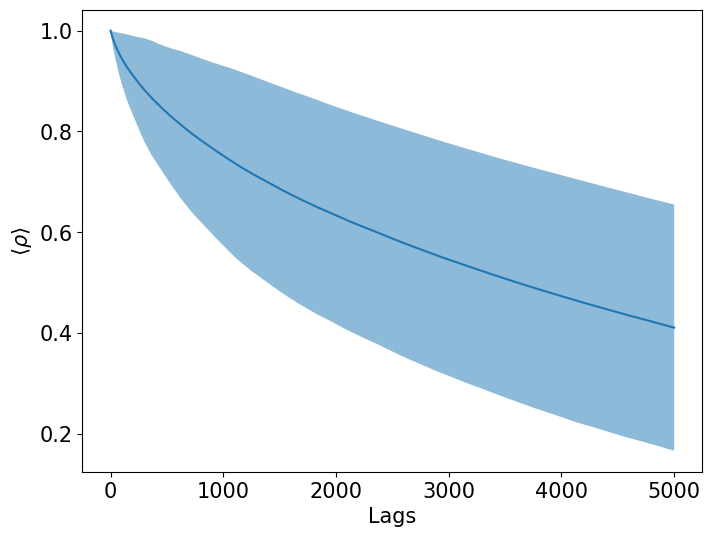

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='Lags', ylabel='$\\langle \\rho \\rangle$'>)

In [ ]:
#AUTOCORRELATION


def plot_acf(lnks, n_iter, n_chains, nlags):
    acfs = np.array([[acf(lnks[i,:,j], nlags=nlags) for j in range(lnks.shape[2])] for i in range(n_chains)])
    acfs = np.array([acfs.reshape((n_chains*lnks.shape[2],acfs.shape[-1]))[i] for i in range(n_chains*lnks.shape[2]) if np.any(np.isnan(acfs.reshape((n_chains*lnks.shape[2],acfs.shape[-1]))[i]))==False])
    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(range(acfs.shape[1]), np.mean(acfs, axis=0))
    ax.fill_between(range(acfs.shape[1]), np.mean(acfs, axis=0)-np.std(acfs, axis=0), np.mean(acfs, axis=0)+np.std(acfs, axis=0), alpha=0.5)
    ax.set_xlabel('Lags', fontsize=15)
    ax.set_ylabel(r'$\langle \rho \rangle$', fontsize=15)
    ax.tick_params(axis='both', labelsize=15)
    plt.show()
    return fig, ax

plot_acf(lnks, n_iter, n_chains, 5000)

